## Discovery – Zone & branchements

Ce notebook sert à **choisir la zone** (FOCUS_LAT, FOCUS_LON), visualiser les trajectoires et les branchements.  
Le graphe utilisé pour le GNN est construit dans **`build_zone_graph.ipynb`** (tous les navires dans la zone uniquement).

# GNN_model: build a route graph from AIS per-ship data, then run shortest-path


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

base_dir = Path("/users/eleves-b/2023/marc.saade/bachelor-thesis/thesis")
by_ship_dir = base_dir / "data" / "processed" / "by_ship"

In [2]:
# List all per-ship parquet files and keep only ships with many AIS points (longer routes)
ship_files = list(by_ship_dir.glob("MMSI_*.parquet"))
candidates = []
for f in ship_files:
    df = pd.read_parquet(f)
    if len(df) >= 500:  # Minimum 500 points AIS per ship
        mmsi = int(df["mmsi"].iloc[0])
        candidates.append((mmsi, f, len(df)))

# Sort by point count (desc) and use ALL ships (no limit)
candidates = sorted(candidates, key=lambda x: x[2], reverse=True)[:2500]  # Removed [:5000] to use all ships
routes = []
for mmsi, f, n in candidates:
    df = pd.read_parquet(f).copy()
    df["MMSI"] = mmsi
    routes.append(df)

routes_df = pd.concat(routes, ignore_index=True)

In [3]:
# === Config léger pour la grille (sans reconstruire G) ===

# Doit correspondre à ce que tu as utilisé quand tu as construit G
LAT_STEP = 0.01   # ≈ 1 km
LON_STEP = 0.01   # ≈ 1 km

print("LAT_STEP:", LAT_STEP, "LON_STEP:", LON_STEP)

LAT_STEP: 0.01 LON_STEP: 0.01


In [7]:
# Build route graph: nodes = grid cells, edges = ship moves between cells (with distance)
from math import radians, sin, cos, sqrt, atan2

LAT_STEP = 0.01  # grid cell size in degrees (≈ 1 km)
LON_STEP = 0.01

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c


def build_route_graph(df: pd.DataFrame, lat_step=LAT_STEP, lon_step=LON_STEP):
    # Sort by ship and time so we traverse trajectories in order
    df = df.sort_values(["MMSI", "base_date_time"]).copy()

    # Assign each (LAT, LON) to a grid cell (bin) and unique node id
    df["lat_bin"] = (df["LAT"] / lat_step).round().astype(int)
    df["lon_bin"] = (df["LON"] / lon_step).round().astype(int)

    # Map (lat_bin, lon_bin) to node id
    df["node_key"] = list(zip(df["lat_bin"], df["lon_bin"]))
    unique_nodes = df[["node_key", "LAT", "LON"]].groupby("node_key").agg({"LAT": "mean", "LON": "mean"}).reset_index()
    node_id_map = {key: i for i, key in enumerate(unique_nodes["node_key"])}

    G = nx.DiGraph()
    for key, lat, lon in unique_nodes[["node_key", "LAT", "LON"]].itertuples(index=False):
        G.add_node(node_id_map[key], lat=lat, lon=lon)

    # For each ship, add directed edges between successive grid cells (skip same-cell moves)
    for mmsi, ship_df in df.groupby("MMSI"):
        ship_df = ship_df.reset_index(drop=True)
        for i in range(len(ship_df) - 1):
            a = ship_df.loc[i]
            b = ship_df.loc[i + 1]
            nid_a = node_id_map[a["node_key"]]
            nid_b = node_id_map[b["node_key"]]
            if nid_a == nid_b:
                continue
            dist = haversine_km(a["LAT"], a["LON"], b["LAT"], b["LON"])
            if G.has_edge(nid_a, nid_b):
                G[nid_a][nid_b]["count"] += 1
                G[nid_a][nid_b]["total_dist_km"] += dist
            else:
                G.add_edge(nid_a, nid_b, count=1, total_dist_km=dist)

    return G

G = build_route_graph(routes_df)



In [8]:
# Save G to disk so you never lose it (e.g. after WiFi disconnect)
import pickle
graph_path = base_dir / "graph_thesis.pkl"
with open(graph_path, "wb") as f:
    pickle.dump(G, f)
print(f"G saved to {graph_path}")
print(f"Nodes: {G.number_of_nodes():,}, Edges: {G.number_of_edges():,}")

G saved to /users/eleves-b/2023/marc.saade/bachelor-thesis/thesis/graph_thesis.pkl
Nodes: 192,361, Edges: 325,691


Loaded G from /users/eleves-b/2023/marc.saade/bachelor-thesis/thesis/graph_thesis.pkl
Nodes: 192,361, Edges: 325,691
EAST_LAT: (10, 50) EAST_LON: (-90, -50)
FOCUS_LAT: (15, 40) FOCUS_LON: (-100, -60)
Focus subgraph: 63,318 nodes, 113,099 edges


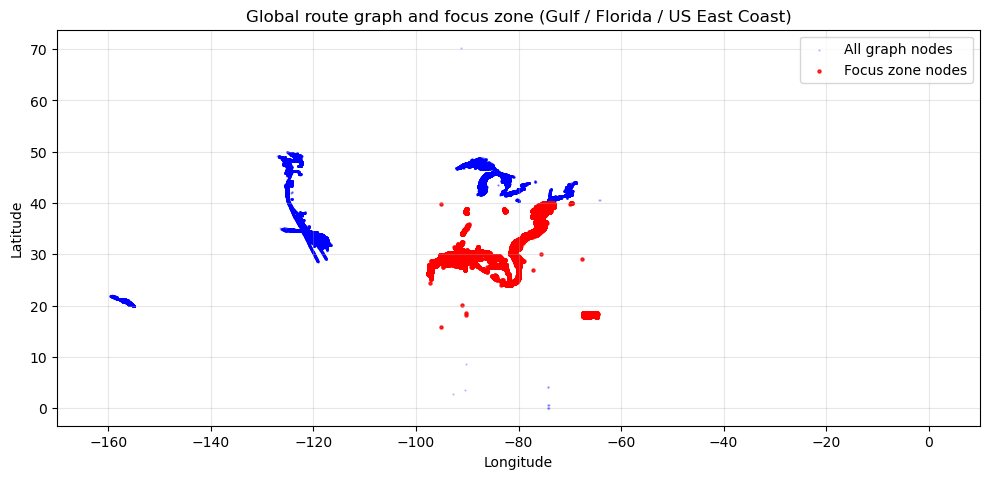

In [4]:
# Reload G from disk, define analysis zones, and visualize before GNN work

import pickle

# Reload the saved route graph (safe even if G is already in memory)
graph_path = base_dir / "graph_thesis.pkl"
with open(graph_path, "rb") as f:
    G = pickle.load(f)

print(f"Loaded G from {graph_path}")
print(f"Nodes: {G.number_of_nodes():,}, Edges: {G.number_of_edges():,}")

# Broad eastern box (for intuition)
EAST_LAT = (10, 50)
EAST_LON = (-90, -50)
# Final focus zone used in the thesis (Gulf + Florida + US East Coast)
FOCUS_LAT = (15, 40)
FOCUS_LON = (-100, -60)
print("EAST_LAT:", EAST_LAT, "EAST_LON:", EAST_LON)
print("FOCUS_LAT:", FOCUS_LAT, "FOCUS_LON:", FOCUS_LON)
def subgraph_in_bbox(G, lat_range, lon_range):
    nodes = [
        n for n, d in G.nodes(data=True)
        if lat_range[0] <= d["lat"] <= lat_range[1]
        and lon_range[0] <= d["lon"] <= lon_range[1]
    ]
    return G.subgraph(nodes).copy()
G_focus = subgraph_in_bbox(G, FOCUS_LAT, FOCUS_LON)
print(f"Focus subgraph: {G_focus.number_of_nodes():,} nodes, {G_focus.number_of_edges():,} edges")
# Visualize global graph and focus zone nodes
lats_all = [G.nodes[n]["lat"] for n in G.nodes()]
lons_all = [G.nodes[n]["lon"] for n in G.nodes()]
lats_focus = [G_focus.nodes[n]["lat"] for n in G_focus.nodes()]
lons_focus = [G_focus.nodes[n]["lon"] for n in G_focus.nodes()]
plt.figure(figsize=(10, 8))
plt.scatter(lons_all, lats_all, s=0.5, alpha=0.2, c="blue", label="All graph nodes")
plt.scatter(lons_focus, lats_focus, s=5, alpha=0.8, c="red", label="Focus zone nodes")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Global route graph and focus zone (Gulf / Florida / US East Coast)")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.3)
plt.xlim(-170, 10)  # même vue que la figure 1: uniquement l’hémisphère Ouest
plt.tight_layout()
plt.legend()
plt.show()

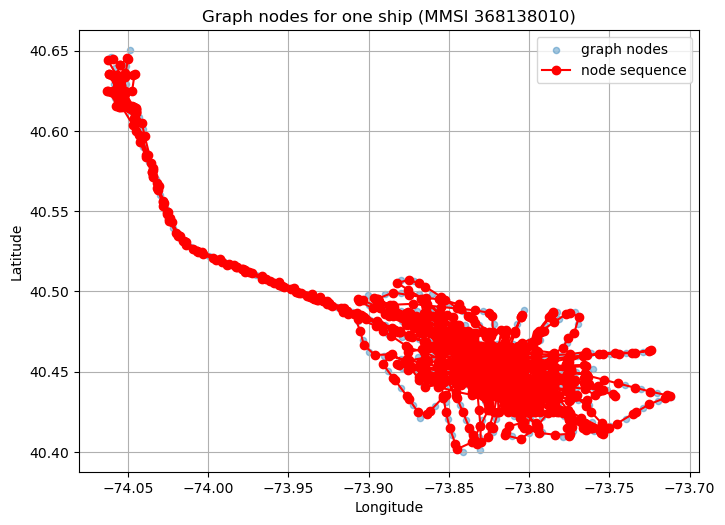

In [5]:
# Show how one ship's trajectory becomes a sequence of graph nodes
if len(candidates) == 0:
    print("No candidate ships found.")
else:
    mmsi, f, n = candidates[0]
    ship = pd.read_parquet(f).copy()
    
    ship = ship.sort_values("base_date_time").reset_index(drop=True)
    # Use same grid resolution as the graph
    ship["lat_bin"] = (ship["LAT"] / LAT_STEP).round().astype(int)
    ship["lon_bin"] = (ship["LON"] / LON_STEP).round().astype(int)
    ship["node_key"] = list(zip(ship["lat_bin"], ship["lon_bin"]))

    unique_nodes = (
        ship[["node_key", "LAT", "LON"]]
        .groupby("node_key")
        .agg({"LAT": "mean", "LON": "mean"})
        .reset_index()
    )
    node_id_map = {key: i for i, key in enumerate(unique_nodes["node_key"])}
    ship["node_id"] = ship["node_key"].map(node_id_map)
    # Drop consecutive duplicates to get node sequence over time
    seq = ship.loc[ship["node_id"].shift().ne(ship["node_id"])]

    plt.figure(figsize=(8, 8))
    plt.scatter(unique_nodes["LON"], unique_nodes["LAT"], s=20, alpha=0.4, label="graph nodes")
    plt.plot(seq["LON"], seq["LAT"], "-o", color="red", label="node sequence")
    plt.title(f"Graph nodes for one ship (MMSI {mmsi})")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(True)
    plt.legend()
    plt.show()

In [6]:
# ⚠️ VERY HEAVY CELL — DO NOT RUN FOR NOW
# (AIS point-level graph for training the GNN, tens of millions of nodes)
# --- AIS point-level graph for GNN ---
# Nodes = individual AIS messages; Edges = consecutive AIS points of the same ship

# Sort all candidate routes by ship and time, then assign a node id per AIS point
points_df = routes_df.sort_values(["MMSI", "base_date_time"]).reset_index(drop=True)
points_df["node_id"] = np.arange(len(points_df))

# Node features (you can adjust this list later if needed)
feature_cols = [
    "LAT", "LON",           # position
    "sog", "cog", "heading",  # kinematics
    "length", "width", "draft",  # ship size
    "vessel_type", "status",      # categorical codes
]
X = points_df[feature_cols].fillna(0).to_numpy(dtype=np.float32)  # shape: [N_nodes, N_features]

# Temporal AIS-to-AIS edges: connect consecutive points of the same MMSI
src_nodes = []
dst_nodes = []
edge_dt_sec = []  # edge feature: time gap in seconds

for mmsi, g in points_df.groupby("MMSI"):
    idx = g["node_id"].to_numpy()
    if len(idx) < 2:
        continue
    # consecutive node pairs
    src_nodes.extend(idx[:-1])
    dst_nodes.extend(idx[1:])

    # time gaps between consecutive AIS points (in seconds)
    ts = pd.to_datetime(g["base_date_time"]).to_numpy()
    dt = (ts[1:] - ts[:-1]) / np.timedelta64(1, "s")
    edge_dt_sec.extend(dt)

edge_index = np.vstack([src_nodes, dst_nodes]).astype(np.int64)  # shape: [2, N_edges]
edge_attr = np.array(edge_dt_sec, dtype=np.float32).reshape(-1, 1)  # optional edge features

print(f"Point-graph: {len(points_df)} nodes, {edge_index.shape[1]} temporal edges")
print("Node feature matrix X shape:", X.shape)
print("edge_index shape:", edge_index.shape)
print("edge_attr (dt_sec) shape:", edge_attr.shape)

KeyboardInterrupt: 

Number of nodes: 192,361
Latitude:  0.07 to 70.28
Longitude: -159.59 to 144.84


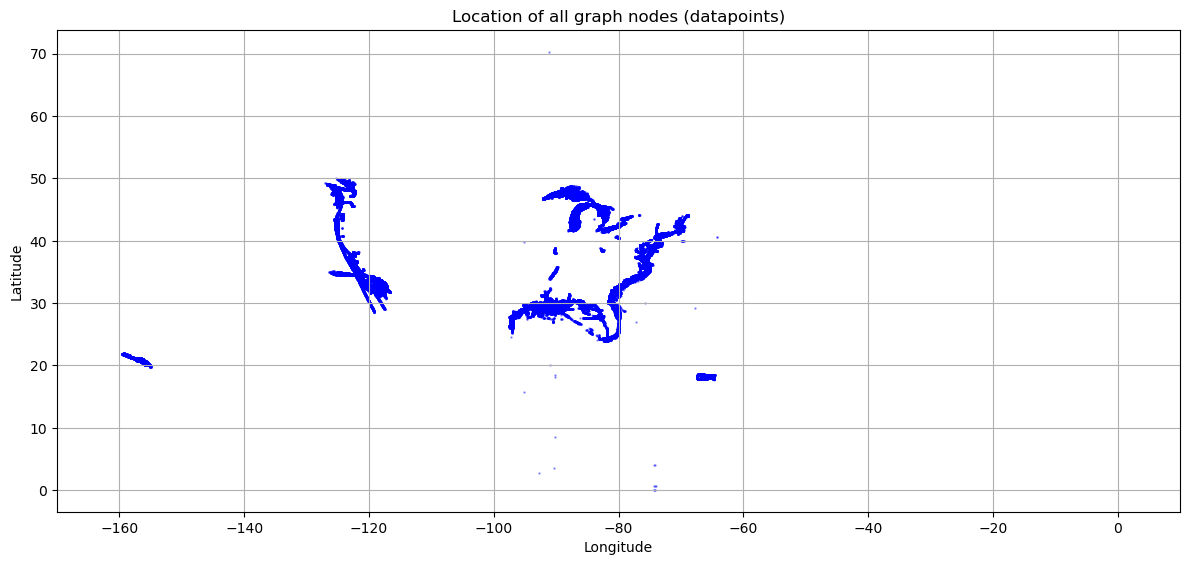

In [7]:
# === Où sont mes datapoints ? (vue globale du graphe) ===
lats = [G.nodes[n]["lat"] for n in G.nodes()]
lons = [G.nodes[n]["lon"] for n in G.nodes()]

print(f"Number of nodes: {len(lats):,}")
print(f"Latitude:  {min(lats):.2f} to {max(lats):.2f}")
print(f"Longitude: {min(lons):.2f} to {max(lons):.2f}")

plt.figure(figsize=(12, 7))
plt.scatter(lons, lats, s=0.5, alpha=0.4, c="blue")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Location of all graph nodes (datapoints)")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True)
plt.tight_layout()

# Option: zoom sur l’Amérique 
plt.xlim(-170, 10)   # seulement l’hémisphère Ouest

plt.show()

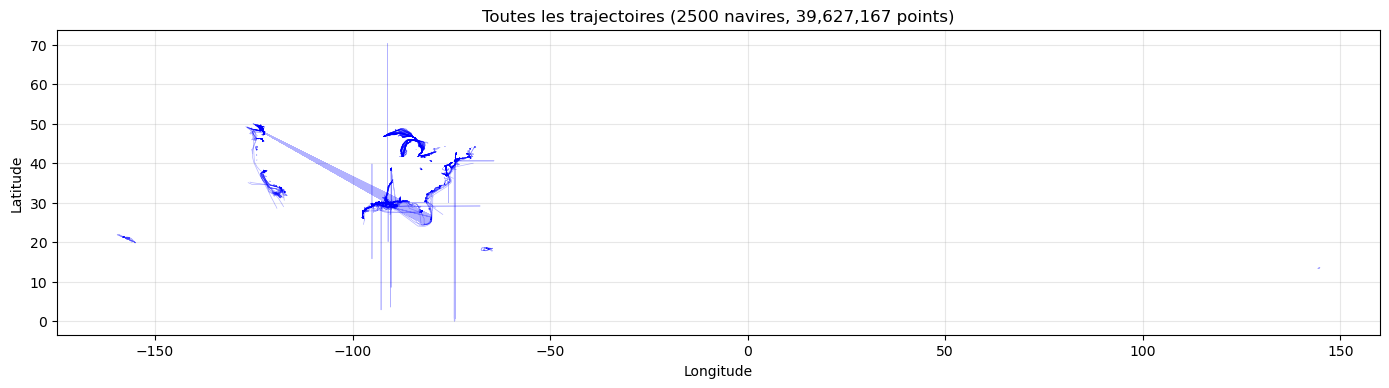

In [8]:
# === 1. Visualiser TOUTES les trajectoires (une ligne par navire) ===
df = routes_df.sort_values(["MMSI", "base_date_time"]).copy()

plt.figure(figsize=(14, 8))
for mmsi, grp in df.groupby("MMSI"):
    grp = grp.reset_index(drop=True)
    plt.plot(grp["LON"], grp["LAT"], alpha=0.3, linewidth=0.5, color="blue")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Toutes les trajectoires ({df['MMSI'].nunique()} navires, {len(df):,} points)")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# === 2. Trouver les BRANCHEMENTS (nœuds visités par plusieurs navires) ===
# Pour chaque nœud du graphe G, compter combien de navires différents y passent
from collections import defaultdict

# Créer un mapping: node_key -> set de MMSI qui passent par ce nœud
node_to_ships = defaultdict(set)

df = routes_df.sort_values(["MMSI", "base_date_time"]).copy()
df["lat_bin"] = (df["LAT"] / LAT_STEP).round().astype(int)
df["lon_bin"] = (df["LON"] / LON_STEP).round().astype(int)
df["node_key"] = list(zip(df["lat_bin"], df["lon_bin"]))

for mmsi, grp in df.groupby("MMSI"):
    unique_nodes = grp["node_key"].unique()
    for node_key in unique_nodes:
        node_to_ships[node_key].add(mmsi)

# Compter le nombre de navires par nœud
branching_nodes = []
for node_key, ships in node_to_ships.items():
    if len(ships) > 1:  # Branchement = au moins 2 navires différents
        branching_nodes.append((node_key, len(ships)))

branching_nodes.sort(key=lambda x: x[1], reverse=True)  # Trier par nombre de navires

print(f"Nombre de branchements trouvés: {len(branching_nodes):,}")
print(f"Branchement le plus fréquenté: {branching_nodes[0][1]} navires différents")
print(f"Top 10 branchements:")
for i, (node_key, count) in enumerate(branching_nodes[:10]):
    print(f"  {i+1}. {node_key}: {count} navires")

Nombre de branchements trouvés: 72,952
Branchement le plus fréquenté: 353 navires différents
Top 10 branchements:
  1. (2976, -9508): 353 navires
  2. (2970, -9502): 338 navires
  3. (2962, -9496): 337 navires
  4. (2963, -9496): 337 navires
  5. (2971, -9502): 337 navires
  6. (2968, -9498): 336 navires
  7. (2972, -9502): 336 navires
  8. (2969, -9498): 335 navires
  9. (2973, -9505): 335 navires
  10. (2976, -9507): 335 navires


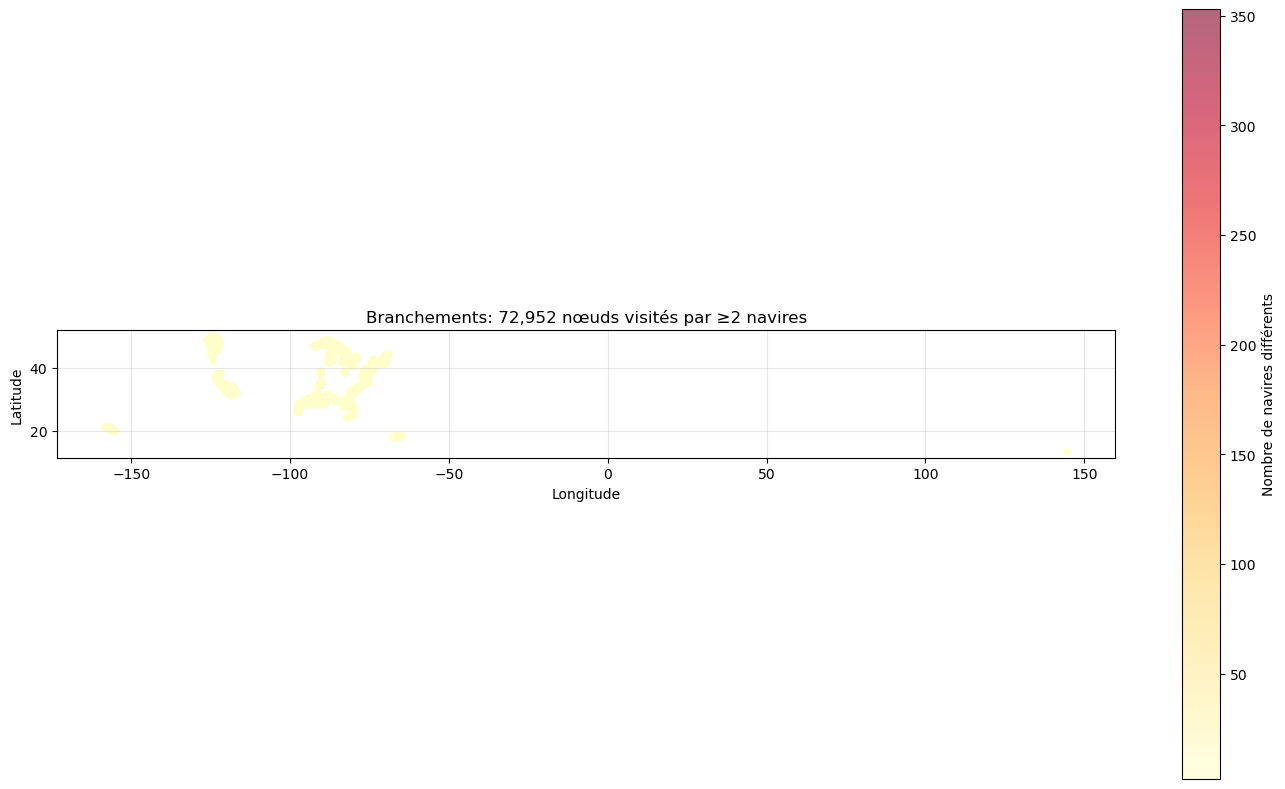

In [10]:
# === 3. Visualiser les BRANCHEMENTS avec intensité (couleur = nombre de navires) ===
# Créer un mapping node_key -> (lat, lon, count) - méthode optimisée
node_coords = {}
# Créer un mapping inverse: node_key -> node_id dans G
node_key_to_id = {}
for n in G.nodes():
    lat = G.nodes[n]["lat"]
    lon = G.nodes[n]["lon"]
    key = (int(round(lat / LAT_STEP)), int(round(lon / LON_STEP)))
    node_key_to_id[key] = n

# Maintenant on peut rapidement trouver les coordonnées
for node_key, ships in node_to_ships.items():
    if len(ships) > 1:  # Seulement les branchements
        if node_key in node_key_to_id:
            n = node_key_to_id[node_key]
            node_coords[node_key] = (G.nodes[n]["lat"], G.nodes[n]["lon"], len(ships))

# Extraire les données pour le plot
branch_lats = [coords[0] for coords in node_coords.values()]
branch_lons = [coords[1] for coords in node_coords.values()]
branch_counts = [coords[2] for coords in node_coords.values()]

# Plot avec couleur selon le nombre de navires
plt.figure(figsize=(14, 8))
scatter = plt.scatter(branch_lons, branch_lats, c=branch_counts, s=20, alpha=0.6, 
                     cmap="YlOrRd", vmin=2, vmax=max(branch_counts))
plt.colorbar(scatter, label="Nombre de navires différents")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Branchements: {len(node_coords):,} nœuds visités par ≥2 navires")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

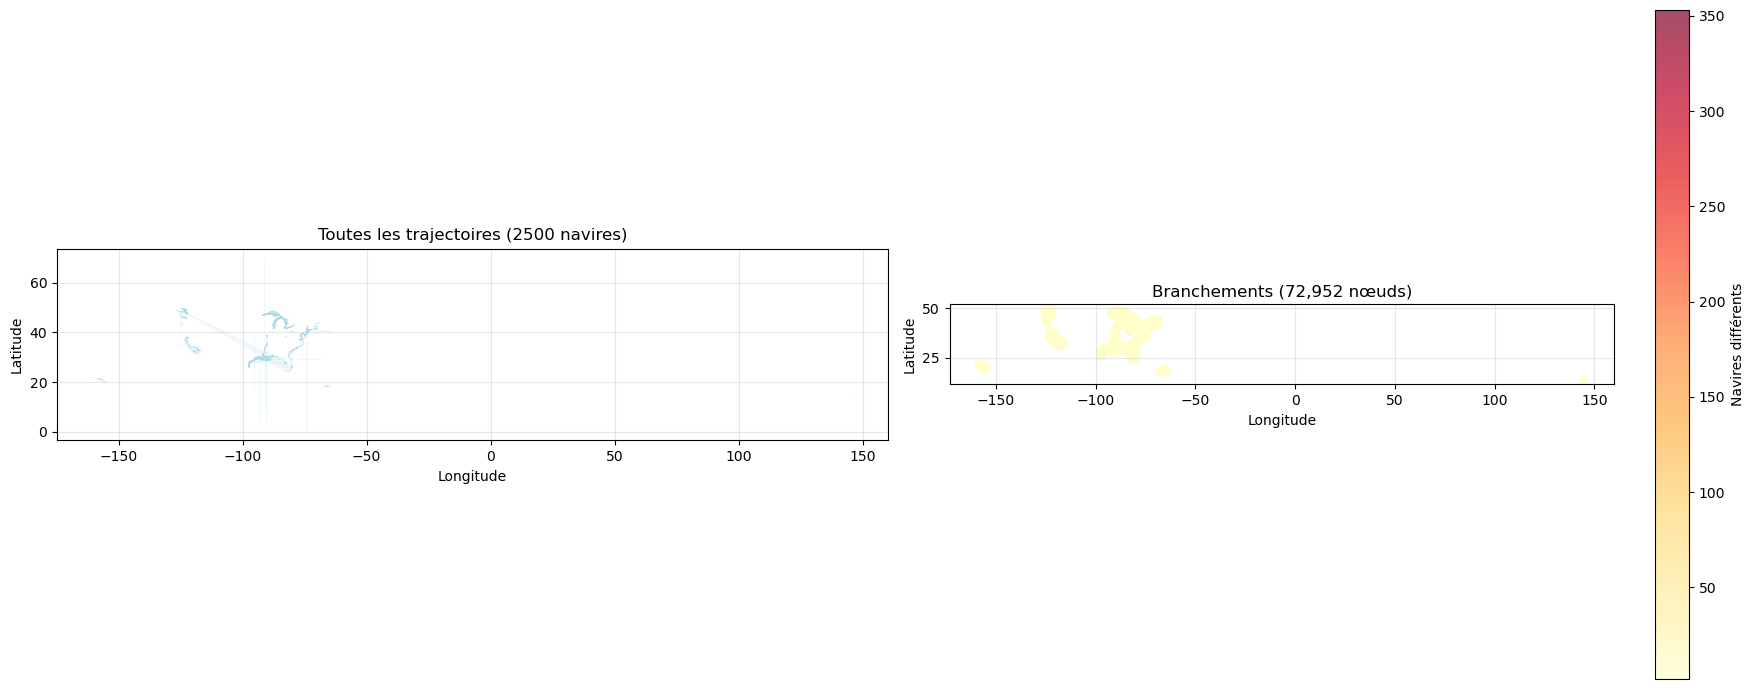

In [11]:
# === 4. Visualiser trajectoires + branchements ensemble ===
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gauche: Toutes les trajectoires
ax1 = axes[0]
for mmsi, grp in df.groupby("MMSI"):
    grp = grp.reset_index(drop=True)
    ax1.plot(grp["LON"], grp["LAT"], alpha=0.2, linewidth=0.3, color="lightblue")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title(f"Toutes les trajectoires ({df['MMSI'].nunique()} navires)")
ax1.set_aspect("equal", adjustable="box")
ax1.grid(True, alpha=0.3)

# Droite: Branchements seulement
ax2 = axes[1]
scatter = ax2.scatter(branch_lons, branch_lats, c=branch_counts, s=30, alpha=0.7, 
                     cmap="YlOrRd", vmin=2, vmax=max(branch_counts))
plt.colorbar(scatter, ax=ax2, label="Navires différents")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_title(f"Branchements ({len(node_coords):,} nœuds)")
ax2.set_aspect("equal", adjustable="box")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

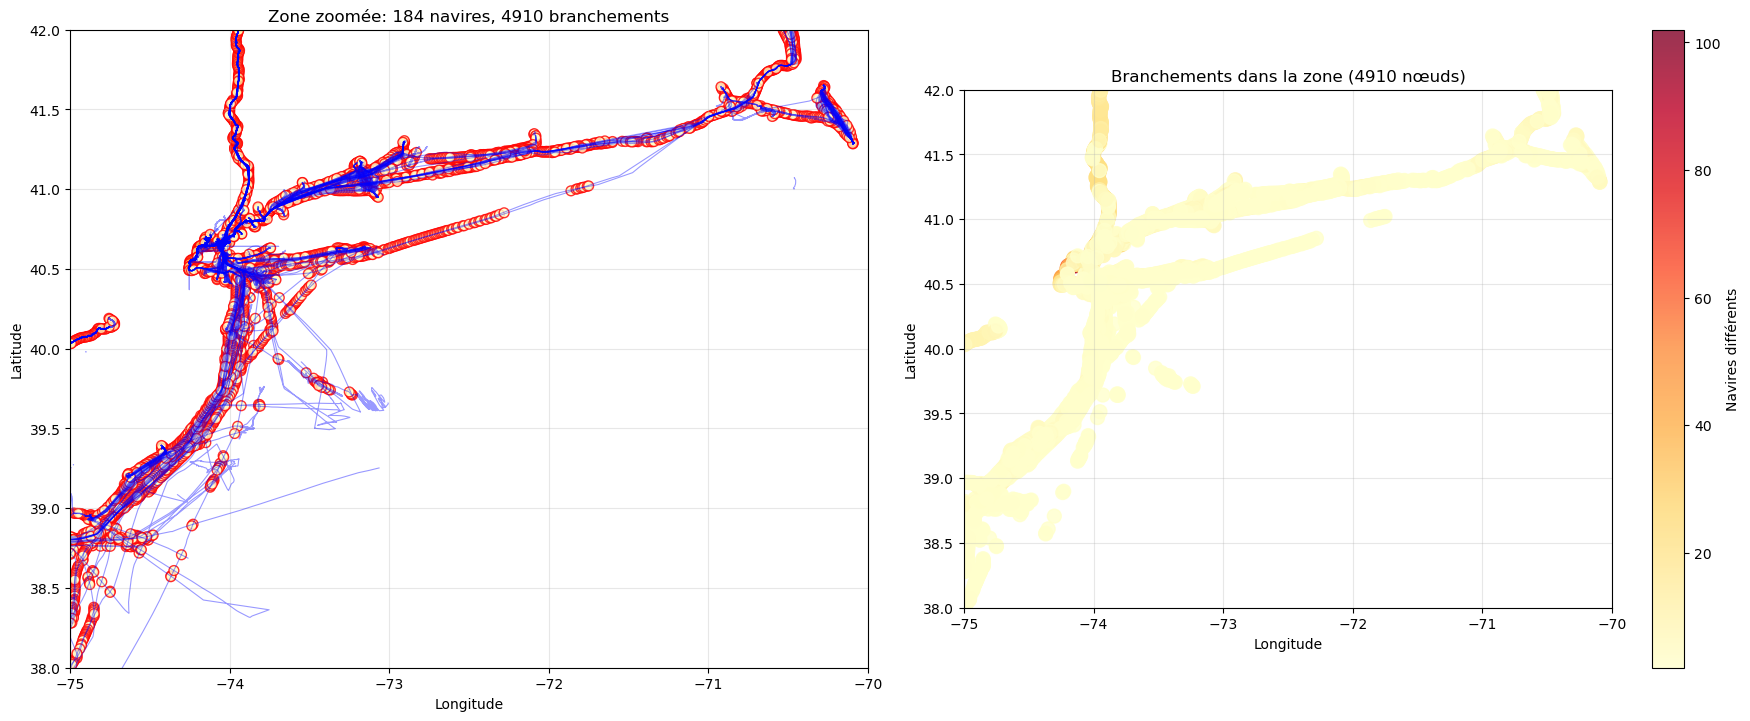

In [12]:
# === 5. Zoomer sur une zone spécifique (modifie les coordonnées ci-dessous) ===
# Exemple: zone autour de New York
ZOOM_LAT = (38, 42)   # Latitude min, max
ZOOM_LON = (-75, -70)  # Longitude min, max

# Filtrer les données dans cette zone
mask_traj = (
    (df["LAT"] >= ZOOM_LAT[0]) & (df["LAT"] <= ZOOM_LAT[1]) &
    (df["LON"] >= ZOOM_LON[0]) & (df["LON"] <= ZOOM_LON[1])
)
df_zoom = df[mask_traj].copy()

mask_branch = (
    (np.array(branch_lats) >= ZOOM_LAT[0]) & (np.array(branch_lats) <= ZOOM_LAT[1]) &
    (np.array(branch_lons) >= ZOOM_LON[0]) & (np.array(branch_lons) <= ZOOM_LON[1])
)
branch_lats_zoom = np.array(branch_lats)[mask_branch]
branch_lons_zoom = np.array(branch_lons)[mask_branch]
branch_counts_zoom = np.array(branch_counts)[mask_branch]

# Plot zoomé
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gauche: Trajectoires dans la zone
ax1 = axes[0]
for mmsi, grp in df_zoom.groupby("MMSI"):
    grp = grp.reset_index(drop=True)
    ax1.plot(grp["LON"], grp["LAT"], alpha=0.4, linewidth=0.8, color="blue")
if len(branch_lats_zoom) > 0:
    ax1.scatter(branch_lons_zoom, branch_lats_zoom, c=branch_counts_zoom, s=50, 
               alpha=0.8, cmap="YlOrRd", vmin=2, vmax=max(branch_counts_zoom), 
               edgecolors="red", linewidths=1)
ax1.set_xlim(ZOOM_LON[0], ZOOM_LON[1])
ax1.set_ylim(ZOOM_LAT[0], ZOOM_LAT[1])
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title(f"Zone zoomée: {df_zoom['MMSI'].nunique()} navires, {len(branch_lats_zoom)} branchements")
ax1.set_aspect("equal", adjustable="box")
ax1.grid(True, alpha=0.3)

# Droite: Branchements seulement dans la zone
ax2 = axes[1]
if len(branch_lats_zoom) > 0:
    scatter = ax2.scatter(branch_lons_zoom, branch_lats_zoom, c=branch_counts_zoom, 
                         s=100, alpha=0.8, cmap="YlOrRd", vmin=2, vmax=max(branch_counts_zoom))
    plt.colorbar(scatter, ax=ax2, label="Navires différents")
ax2.set_xlim(ZOOM_LON[0], ZOOM_LON[1])
ax2.set_ylim(ZOOM_LAT[0], ZOOM_LAT[1])
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_title(f"Branchements dans la zone ({len(branch_lats_zoom)} nœuds)")
ax2.set_aspect("equal", adjustable="box")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()